In [2]:
import numpy as np
from matplotlib import pyplot as plt

In [279]:
%run ODE/lib.ipynb

In [3]:
from scipy.integrate import solve_ivp

**Background**: 

When a star of mass $m_{\star}$ and radius $R_{\star}$ passes within the tidal radius

$$
\begin{equation*}
R_T \approx R_{\star}\left(\frac{M_{\bullet}}{m_{\star}}\right)^{1 / 3} 
\end{equation*}
$$

of a black hole of mass $M_{\bullet}$, tidal forces exceed the star's self-gravity and the star is disrupted. The bound fraction of the debris returns to pericentre at a rate $\dot{M}(t)$ that at late times follows the well-known power law $\dot{M} \propto t^{-5 / 3}$. The goal of this exercise is to derive and test this scaling numerically, starting from the orbital dynamics, and to explore how general-relativistic corrections modify it.

**Step 1 - Stellar centre-of-mass orbit**: 

Integrate the equation of motion for the stellar centre of mass:

$$
\begin{equation*}
\ddot{\mathbf{r}}=-\frac{G M_{\bullet}}{r^3} \mathbf{r}+\mathbf{a}_{\mathrm{PN}}(\mathbf{r}, \dot{\mathbf{r}}), 
\end{equation*}
$$

where $\mathbf{a}_{\mathrm{PN}}$ is the leading-order post-Newtonian correction (1PN, $q \rightarrow 0$ limit):

$$
\begin{equation*}
\mathbf{a}_{\mathrm{PN}}=\frac{G M_{\bullet}}{c^2 r^3}\left[\left(4 \frac{G M_{\bullet}}{r}-v^2\right) \mathbf{r}+4(\mathbf{r} \cdot \dot{\mathbf{r}}) \dot{\mathbf{r}}\right] . 
\end{equation*}
$$

Set $\mathbf{a}_{\mathrm{PN}}=\mathbf{0}$ to recover the Newtonian case. Use initial conditions corresponding to a parabolic orbit ( $E_{\mathrm{cm}}=0, e=1$ ) with pericentre $r_p=\beta R_T$. Adopt an adaptive integrator (e.g. RK45) with event detection to stop the integration when $r=r_p$ and record the pericentre velocity $\mathbf{v}_p$.

In [4]:
G = 1.
c = 1.
M = 1.

In [5]:
def unpack(y):
    r = np.array([y[0],y[2],y[4]])
    rdot = np.array([y[1],y[3],y[5]])
    return r, rdot

In [6]:
def f_prime(t, y):
    r, rdot = unpack(y)
    r_magn = np.linalg.norm(r)
    v_magn = np.linalg.norm(rdot)

    GM_r3 = G*M/(r_magn**3)
    
    #aPN = GM_r3/c**2 * ( ( 4*G*M/r_magn - v_magn**2 ) * r + 4*np.dot(r,rdot)*rdot )
    aPN = 0

    rdd = - GM_r3*r + aPN
    return rdot[0], rdd[0], rdot[1], rdd[1], rdot[2], rdd[2]

In [7]:
mstar = 1e-3 * M
Rstar = 1e-3
RT = Rstar * (M / mstar)**(1/3)
beta = 1/10

In [8]:
# INITIAL CONDITIONS
r_p = beta * RT
r0 = 10
v0 = np.sqrt(2*G*(M+mstar)/r0)

In [9]:
def two_body_ic_hyperbolic_from_rp(m1, m2, rp, e, start_factor, omega_deg=0.0):

    M = m1 + m2
    omega = np.radians(omega_deg)
    p = rp * (1.0 + e) # semilato retto

    r0 = start_factor * rp

    cos_phi0 = (p / r0 - 1.0) / e # angolo vero iniziale sul ramo entrante

    phi0 = -np.arccos(cos_phi0)   
    theta0 = phi0 + omega

    r_rel = np.array([
        r0 * np.cos(theta0),
        r0 * np.sin(theta0),
        0.0
    ], dtype=float)

    # velocità relativa in coordinate polari
    fac = np.sqrt(G * M / p)
    vr0 = fac * e * np.sin(phi0)
    vt0 = fac * (1.0 + e * np.cos(phi0))

    # velocità relativa in cartesiane
    v_rel = np.array([
        vr0 * np.cos(theta0) - vt0 * np.sin(theta0),
        vr0 * np.sin(theta0) + vt0 * np.cos(theta0),
        0.0
    ], dtype=float)

    # frame del centro di massa
    r1 = -(m2 / M) * r_rel
    r2 = +(m1 / M) * r_rel
    v1 = -(m2 / M) * v_rel
    v2 = +(m1 / M) * v_rel

    # diagnostica orbitale
    h = np.linalg.norm(np.cross(r_rel, v_rel))               # specific angular momentum
    eps = 0.5 * np.dot(v_rel, v_rel) - G * M / np.linalg.norm(r_rel)  # specific energy
    a = -G * M / (2.0 * eps)                                 # negativo per iperbole
    vinf = np.sqrt(2.0 * eps)
    b = h / vinf
    rp_check = h**2 / (G * M * (1.0 + e))

    return {
        "r_rel": r_rel,
        "v_rel": v_rel,
        "r1": r1,
        "r2": r2,
        "v1": v1,
        "v2": v2
    }

In [10]:
ic = two_body_ic_hyperbolic_from_rp(M, mstar, r_p, e=1, start_factor=10.5)

v_0 = ic['v_rel']
r_0 = ic['r_rel']
y0 = [r_0[0], v_0[0], r_0[1], v_0[1], r_0[2], v_0[2]]
y0

[-0.008499999999999997,
 13.134227670782037,
 -0.006164414002968975,
 4.261306156418495,
 0.0,
 0.0]

In [11]:
r_p_vec = np.array([r_p,0,0])

In [12]:
def stop_ev(t, y, r_min = 1e-11):
    r,v = unpack(y)
    return (r[0] - r_p) - r_min

In [13]:
def pericentre_event(t, y, GM_bh, c_sq, a_PN_flag):
    #Triggers when radial velocity changes from negative to positive.
    rx, ry, vx, vy = y
    r = np.linalg.norm(np.array([rx, ry]))
    r_dot = (rx * vx + ry * vy) / r
    return r_dot

pericentre_event.direction = -1
pericentre_event.terminal = False

In [14]:
h = 0.0001
tf = .005

t_span =  [0,tf]


t_ev = np.linspace(0,tf,int(1e8))
stop_ev.terminal = True
#stop_ev.direction = -1
sol = solve_ivp(f_prime, t_span, y0, t_eval=t_ev, events=stop_ev, rtol=1e-11, atol=1e-11)

In [15]:
sol

  message: A termination event occurred.
  success: True
   status: 1
        t: [ 0.000e+00  5.000e-11 ...  5.729e-04  5.729e-04]
        y: [[-8.500e-03 -8.500e-03 ...  1.000e-03  1.000e-03]
            [ 1.313e+01  1.313e+01 ...  1.343e+00  1.343e+00]
            ...
            [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
            [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]]
      sol: None
 t_events: [array([ 5.729e-04])]
 y_events: [array([[ 1.000e-03,  1.343e+00, -5.960e-05,  4.466e+01,
                    0.000e+00,  0.000e+00]])]
     nfev: 944
     njev: 0
      nlu: 0

In [16]:
norms = []
for i in range(len(sol['y'][::2])): norms = np.append(norms,np.linalg.norm(sol['y'][::2][:,i]))
min(norms),norms,np.linalg.norm(sol['y'][::2][:,0])

(0.01049999868657718, array([0.0105, 0.0105, 0.0105]), 0.010499999999999997)

In [17]:
min(abs(sol['y'][0]-r_p)),r_p

(2.1803795748065458e-12, 0.0009999999999999998)

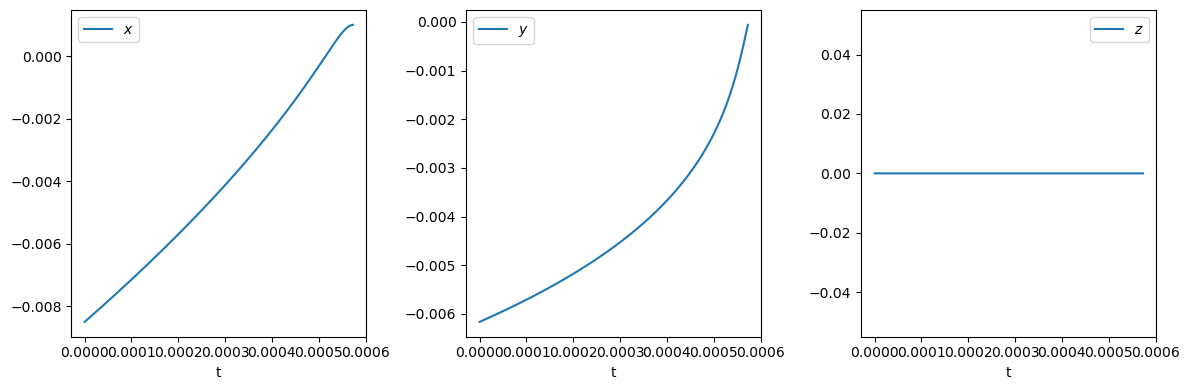

In [18]:
fig, ax = plt.subplots(1,3, figsize=(12,4))
ax[0].plot(sol['t'][::100],sol['y'][0][::100],label=r'$x$')
ax[1].plot(sol['t'][::100],sol['y'][2][::100],label=r'$y$')
ax[2].plot(sol['t'][::100],sol['y'][4][::100],label=r'$z$')
for i in range(3): 
    ax[i].legend()
    ax[i].set_xlabel('t')
    ax[i].set_ylabel('')
plt.tight_layout()

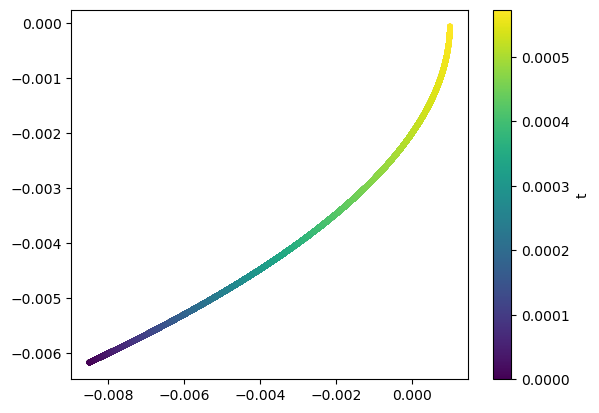

In [19]:
color = sol['t'][::100]
plt.scatter(sol['y'][0][::100],sol['y'][2][::100],c=color,marker='.')
plt.colorbar(label='t')

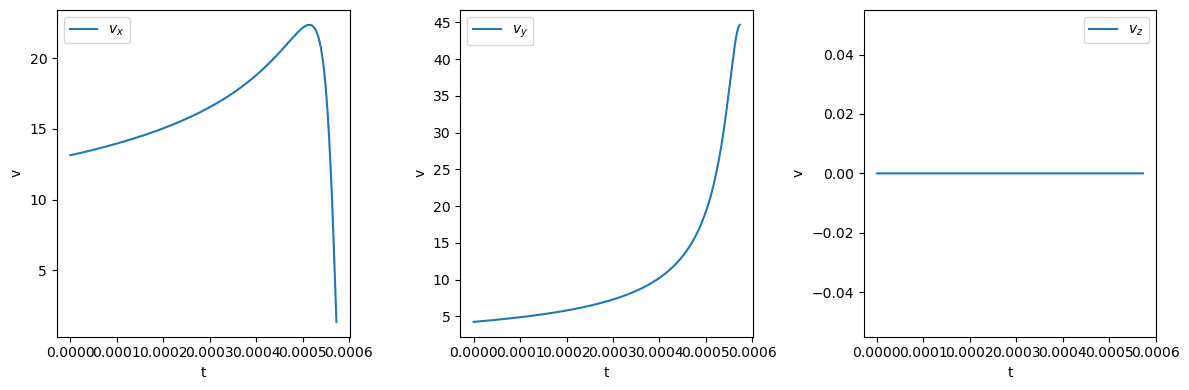

In [20]:
fig, ax = plt.subplots(1,3, figsize=(12,4))
ax[0].plot(sol['t'][::100],sol['y'][1][::100],label=r'$v_x$')
ax[1].plot(sol['t'][::100],sol['y'][3][::100],label=r'$v_y$')
ax[2].plot(sol['t'][::100],sol['y'][5][::100],label=r'$v_z$')
for i in range(3): 
    ax[i].legend()
    ax[i].set_xlabel('t')
    ax[i].set_ylabel('v')
plt.tight_layout()

In [21]:
# v_p = np.array([sol['y'][1][-1], sol['y'][2][-1], sol['y'][2][-1]])
# v_p

In [22]:
t_p = sol.t_events
y_p = sol.y_events
v_p = unpack(y_p[0][0])[1]
v_p

array([ 1.34279516, 44.66368343,  0.        ])

**Step 2 - Debris energy distribution**:

At pericentre, model the disrupted star as $N$ mass elements located at positions $r_p+\delta r_i$ along the radial direction, where $\delta r_i$ is drawn uniformly from $\left[-R_{\star}, R_{\star}\right]$. This is equivalent to assuming a constant-density star; the nonuniform case is treated in the extension below. Each element inherits the centre-of-mass velocity $\mathbf{v}_p$ and acquires a specific orbital energy

$$
\begin{equation*}
E_i=\frac{v_p^2}{2}-\frac{G M_{\bullet}}{r_p+\delta r_i} .
\end{equation*}
$$

The bound debris $\left(E_i<0\right)$ will return to pericentre; the unbound debris $\left(E_i>0\right)$ escapes. Plot the energy distribution $d N / d E$.

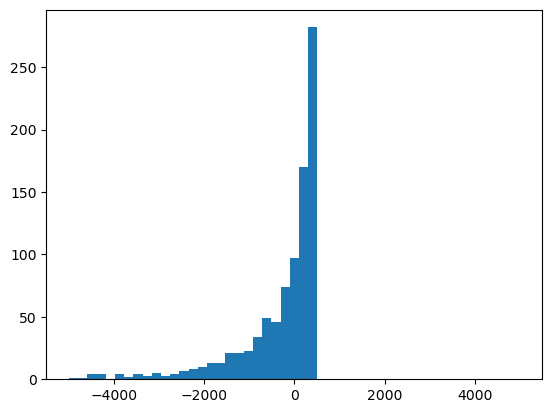

In [23]:
N = 1000
delta_rs = np.random.uniform(-Rstar, Rstar, N)

Es = np.linalg.norm(v_p)**2/2 - G*M/(r_p+delta_rs)
bins = np.linspace(-5000,5000,50)
plt.hist(Es,bins=bins);
#plt.tight_layout()


**Step 3 - Debris return times and fallback rate**:

For each bound debris particle, integrate equation (20) (with the same choice of $\mathbf{a}_{\mathrm{PN}}$ ) starting from $\left(r_p+\delta r_i, \mathbf{v}_p\right)$, and use event detection to find the return time $t_i$ at the next passage through $r=r_p$. In the Newtonian case this can also be computed analytically via Kepler's third law:

$$
\begin{equation*}
t_i^{\mathrm{Kep}}=\frac{\pi G M_{\bullet}}{\left(2\left|E_i\right|\right)^{3 / 2}},
\end{equation*}
$$

which provides an exact benchmark for your integrator. Once the $\left\{t_i\right\}$ are known, sort them and construct the mass fallback rate $\dot{M}(t)=d M / d t$ by numerical differentiation or histogram binning of the cumulative mass distribution.

In [346]:
len(Es[Es<0])

533

In [347]:
delta_rs_bound = delta_rs[Es<0]

In [387]:
h = 0.001
tf = 50

t_span =  [0,tf]


t_ev = np.linspace(0,tf,int(1e7))
stop_ev.terminal = False
stop_ev.direction = -1


In [392]:
ic = two_body_ic_hyperbolic_from_rp(M, mstar, r_p, e=1, start_factor=10.5)

v_0 = ic['v_rel']
r_0 = ic['r_rel']
y0 = [r_0[0], v_0[0], r_0[1], v_0[1], r_0[2], v_0[2]]
y0[1] = y0[1] - delta_rs_bound[0]

In [393]:
sol = solve_ivp(f_prime, t_span, y0, t_eval=t_ev, events=stop_ev, rtol=1e-11, atol=1e-11)

t_evs = sol.t_events
y_evs = sol.y_events

In [394]:
sol

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  5.000e-06 ...  5.000e+01  5.000e+01]
        y: [[-8.500e-03 -8.434e-03 ... -3.158e+01 -3.158e+01]
            [ 1.314e+01  1.317e+01 ... -5.275e-01 -5.275e-01]
            ...
            [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
            [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]]
      sol: None
 t_events: [array([ 5.757e-04])]
 y_events: [array([[ 1.000e-03, -1.513e+00,  6.858e-05,  4.465e+01,
                    0.000e+00,  0.000e+00]])]
     nfev: 4076
     njev: 0
      nlu: 0

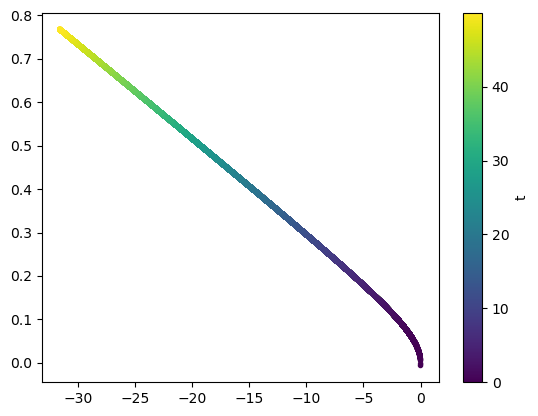

In [395]:
color = sol['t'][::100]
plt.scatter(sol['y'][0][::100],sol['y'][2][::100],c=color,marker='.')
plt.colorbar(label='t')

Suggested Methodology: Adaptive ODE-IVP (RK45 or equivalent) with event detection for Steps 1 and 3; direct summation over $N \gtrsim 10^3$ debris particles; numerical differentiation or binning for $\dot{M}(t)$.

Suggested investigation:
<dl>
<dd> a. Convergence test (Newtonian). Set $\mathbf{a}_{\mathrm{PN}}=\mathbf{0}$. For a single debris particle with energy $E_i=-\delta E / 2$, compare the numerically integrated return time $t_i^{\text {num }}$ with the analytical value $t_i^{\text {Kep }}$ from equation (23) as a function of the integrator tolerance $\varepsilon$. Show that the error $\left|t_i^{\text {num }}-t_i^{\text {Kep }}\right| / t_i^{\text {Kep }}$ decreases with $\varepsilon$ at the expected order of the scheme. Also verify that energy is conserved along the orbit to the same level as $\varepsilon$. </dd>

    
<dd> b. Orbital trajectory. Plot $\mathbf{r}(t)$ for the stellar centre of mass (Newtonian), marking $R_T$ and $r_p$. Confirm that the orbit is parabolic by verifying $E_{\mathrm{cm}}=0$ to numerical precision throughout the integration.</dd>


<dd> c. Tidal force. Plot the tidal force $F_{\text {tidal }}(t)=2 G M_{\bullet} R_{\star} / r^3$ along the orbit. At what time does it peak, and how does the peak value scale with $\beta$?</dd>


<dd> d. Energy distribution. Plot $d M / d E$ for the debris. Show that it is uniform (as expected for a constant-density star) and that the half-width $\delta E$ scales as predicted by equation (22).</dd>


<dd> e. Fallback rate (Newtonian). Using equation (23) for the return times, construct $\dot{M}(t)$ and plot it on a $\log -\log$ scale. Verify the $t^{-5 / 3}$ power law at late times and identify the peak fallback rate $\dot{M}_{\text {peak }}$ and the time to peak $t_{\text {peak }}$. </dd>


<dd> f. Relativistic corrections. Repeat Step 3 with the 1PN correction (21) active. On the same axes, compare $\dot{M}^{\mathrm{PN}}(t)$ with the Newtonian result. How do $\dot{M}_{\text {peak }}$ and $t_{\text {peak }}$ change? For which values of $M_{\bullet}$ and $\beta$ is the correction most significant? </dd>


<dd> g. (Extension) Parameter survey. Vary $\beta \in[1,5]$ and $M_{\bullet} / m_{\star} \in\left[10^5, 10^8\right]$. Characterise the scaling of $\dot{M}_{\text {peak }}$ and $t_{\text {peak }}$ with these parameters and compare with the analytical expectations $\dot{M}_{\text {peak }} \propto M_{\bullet}^{-1 / 2}$ and $t_{\text {peak }} \propto M_{\bullet}^{1 / 2}$. </dd>


<dd> h. (Extension) Non-uniform density profile. Replace the uniform sampling in Step 2 with a weighting proportional to a polytropic density profile $\rho(\delta r) \propto(1-$ $\left.\delta r^2 / R_{\star}^2\right)^n$ for $n=3 / 2$ and $n=3$. How does the shape of $d M / d E$ change, and what is the effect on the early-time behaviour of $\dot{M}(t)$? </dd>
</dl>